# Differentiable Rendering with jaxCAD's Parameter System

jaxCAD's sphere-tracing renderer is fully differentiable — gradients flow through the
march loop, normal computation, and shading. This notebook solves an **inverse-rendering
problem**: given a target photograph (`lada.png`), optimise a scene of SDF primitives so
its rendering minimises pixel-space MSE against the photo.

The full pipeline uses jaxCAD's parameter system end-to-end:

1. Build a `Scene` with geometry, per-primitive `Material`s (colours as free `Vector`
   params), and a `RenderConfig`.
2. `extract_parameters(scene)` yields one `free_params` dict covering geometry,
   materials, and render config — no manual bookkeeping.
3. `functionalize_render(scene)` compiles the scene to a pure
   `(free_params, resolution) → image` JAX function, differentiable via `jax.grad`.
4. Adam optimises `free_params` to minimise pixel-space MSE against the target.

Material colours are stored in `[0, 1]` linear space.  The background colour
(`bg_color`) is the exception: it lives in logit space and is sigmoid-mapped at
render time so it stays unconstrained during optimisation.

In [1]:
import imageio
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from PIL import Image

from jaxcad import functionalize_render
from jaxcad.extraction import extract_parameters
from jaxcad.geometry import Scalar, Vector
from jaxcad.render import Material, RenderConfig, Scene
from jaxcad.sdf import Box, Cylinder, Plane, RoundBox, Translate, Union

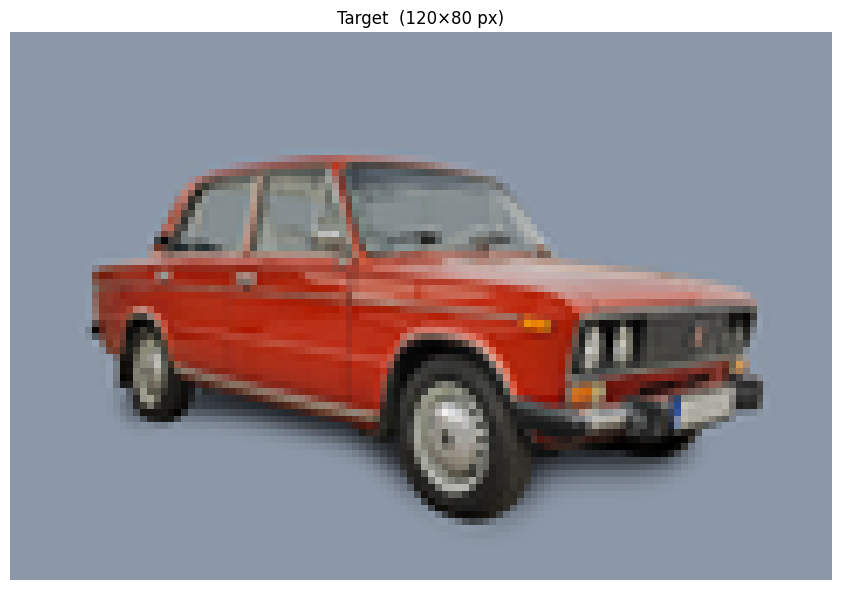

In [2]:
# ── Target image ─────────────────────────────────────────────────────────────
RES = (80, 120)  # (height, width)
SKY = (140, 152, 168)

img_rgba = Image.open("assets/lada.png").convert("RGBA")
bg = Image.new("RGB", img_rgba.size, SKY)
bg.paste(img_rgba.convert("RGB"), mask=img_rgba.split()[3])
target_pil = bg.resize((RES[1], RES[0]), Image.LANCZOS)

target = jnp.array(np.array(target_pil) / 255.0, dtype=jnp.float32)

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(np.array(target))
ax.set_title(f"Target  ({RES[1]}×{RES[0]} px)")
ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
# ── Free geometry parameters ──────────────────────────────────────────────────

# Lower body (chassis + doors) — free size and position
body_pos = Vector([0.0, -0.10, 0.0], free=True, name="body_pos")
body_size = Vector([1.85, 0.42, 0.65], free=True, name="body_size")

# Cabin (passenger compartment on top of body) — free size and position
cabin_pos = Vector([-0.15, 0.73, 0.0], free=True, name="cabin_pos")
cabin_size = Vector([0.90, 0.32, 0.60], free=True, name="cabin_size")

# Hood (front engine cover) — free size and position
hood_pos = Vector([-1.47, 0.18, 0.0], free=True, name="hood_pos")
hood_size = Vector([0.62, 0.12, 0.63], free=True, name="hood_size")

# Trunk (rear boot) — free size and position
trunk_pos = Vector([1.35, 0.14, 0.0], free=True, name="trunk_pos")
trunk_size = Vector([0.48, 0.09, 0.63], free=True, name="trunk_size")

# Bumpers — free positions and sizes
bumper_f_pos = Vector([-1.96, -0.20, 0.0], free=True, name="bumper_f_pos")
bumper_r_pos = Vector([1.96, -0.20, 0.0], free=True, name="bumper_r_pos")
bumper_size = Vector([0.04, 0.18, 0.58], free=True, name="bumper_size")
bumper_radius = Scalar(0.06, free=True, name="bumper_radius")

# Wheels — near-side cylinders (axis along Z so the disc face is camera-side)
wf_pos = Vector([-1.15, -0.65, 0.52], free=True, name="wf_pos")  # front
wr_pos = Vector([1.15, -0.65, 0.52], free=True, name="wr_pos")  # rear
r_wheel = Scalar(0.42, free=True, name="r_wheel")  # shared radius
wh_wheel = Scalar(0.18, free=True, name="wh_wheel")  # shared half-thickness

# ── Materials — col_body shared across body/cabin/hood/trunk (deduplicated) ────
col_body = Vector([0.55, 0.14, 0.10], free=True, name="col_body")
col_wheel = Vector([0.12, 0.12, 0.12], free=True, name="col_wheel")
col_bumper = Vector([0.72, 0.72, 0.70], free=True, name="col_bumper")
col_ground = Vector([0.40, 0.38, 0.36], free=True, name="col_ground")

body_mat = Material(color=col_body, roughness=0.40, metallic=0.12)
cabin_mat = Material(color=col_body, roughness=0.35, metallic=0.08)
hood_mat = Material(color=col_body, roughness=0.38, metallic=0.12)
wheel_mat = Material(color=col_wheel, roughness=0.70)
bump_mat = Material(color=col_bumper, roughness=0.50, metallic=0.25)
ground_mat = Material(color=col_ground, roughness=0.95, metallic=0.00)

# ── Ground plane (fixed height, receives shadows from the car) ────────────────
GROUND_Y = -1.10
ground = Plane(height=Scalar(GROUND_Y, free=False), material=ground_mat)

# Car parts smoothly blended; ground added as hard union so the car doesn't
# melt into the floor.
car = Union(
    (
        # ── Body structure ────────────────────────────────────────────────────
        Translate(Box(size=body_size, material=body_mat), body_pos),
        Translate(Box(size=cabin_size, material=cabin_mat), cabin_pos),
        Translate(Box(size=hood_size, material=hood_mat), hood_pos),
        Translate(Box(size=trunk_size, material=hood_mat), trunk_pos),
        # ── Bumpers ───────────────────────────────────────────────────────────
        Translate(
            RoundBox(size=bumper_size, radius=bumper_radius, material=bump_mat), bumper_f_pos
        ),
        Translate(
            RoundBox(size=bumper_size, radius=bumper_radius, material=bump_mat), bumper_r_pos
        ),
        # ── Near-side wheels (Z-axis cylinder → disc face toward camera) ──────
        Translate(Cylinder(radius=r_wheel, height=wh_wheel, material=wheel_mat), wf_pos),
        Translate(Cylinder(radius=r_wheel, height=wh_wheel, material=wheel_mat), wr_pos),
    ),
    smoothness=0.12,
)

# Hard union: car + ground (smoothness≈0 → sharp join, no melting)
geometry = Union((car, ground), smoothness=0.0)

# ── Render config with differentiable lights ──────────────────────────────────
render_cfg = RenderConfig(
    camera_pos=Vector([4.0, 2.0, 6.0], free=True, name="camera_pos"),
    look_at=Vector([0.0, 0.0, 0.0], free=False, name="look_at"),
    fov=Scalar(0.55, free=False, name="fov"),
    bg_color=Vector([0.1, 0.25, 0.55], free=True, name="bg_color"),
    light_dirs=[
        Vector([0.45, 0.85, 0.25], free=True, name="light_dir_0"),
        Vector([-0.3, 0.5, -0.2], free=True, name="light_dir_1"),
    ],
    light_colors=[
        Vector([0.95, 0.88, 0.75], free=True, name="light_color_0"),
        Vector([0.3, 0.38, 0.55], free=True, name="light_color_1"),
    ],
)

scene = Scene(geometry, render_cfg)

# ── Extract all free parameters in one shot ───────────────────────────────────
free_params, fixed_params, metadata = extract_parameters(scene)

print("free_params keys:", sorted(free_params.keys()))
print(
    f"\n{len(free_params)} free params, "
    f"{sum(v.size for v in free_params.values())} scalar values"
)

free_params keys: ['bg_color', 'body_pos', 'body_size', 'bumper_f_pos', 'bumper_r_pos', 'bumper_radius', 'bumper_size', 'cabin_pos', 'cabin_size', 'camera_pos', 'col_body', 'col_bumper', 'col_ground', 'col_wheel', 'hood_pos', 'hood_size', 'light_color_0', 'light_color_1', 'light_dir_0', 'light_dir_1', 'r_wheel', 'trunk_pos', 'trunk_size', 'wf_pos', 'wh_wheel', 'wr_pos']

26 free params, 72 scalar values


Rendering initial scene (first run triggers XLA compilation)...
Output shape: (80, 120, 3)


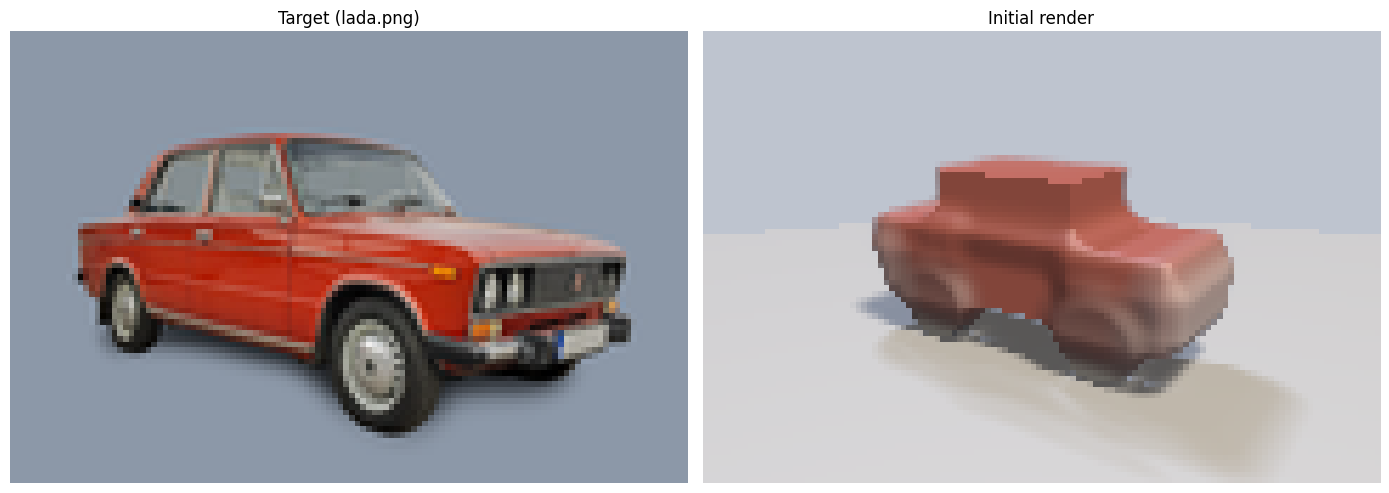

In [27]:
# ── Compile the scene to a differentiable render function ─────────────────────
#
# functionalize_render walks the geometry + material tree, builds pure JAX
# closures for the SDF and material_fn, and wires them into the sphere-tracing
# renderer. The result is a plain function that jax.grad can differentiate
# through entirely.

diff_render = functionalize_render(
    scene,
    max_steps=32,
    shadow_steps=12,
    shadow_hardness=6.0,
    gamma=2.2,
)

print("Rendering initial scene (first run triggers XLA compilation)...")
img0 = diff_render(free_params, resolution=RES)
print(f"Output shape: {img0.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(np.array(target))
axes[0].set_title("Target (lada.png)")
axes[0].axis("off")
axes[1].imshow(np.array(img0))
axes[1].set_title("Initial render")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Optimisation

We minimise mean-squared pixel error with Adam.  `jax.value_and_grad` differentiates
through the compiled render function — sphere-tracing, surface normals, shading, and
the softmax material blend — in one `jax.jit`-compiled call.

In [20]:
def loss_fn(free_params):
    return jnp.mean((diff_render(free_params, resolution=RES) - target) ** 2)


grad_fn = jax.jit(jax.value_and_grad(loss_fn))

N_STEPS = 2000
LR = 0.001
optimizer = optax.adamw(learning_rate=LR)
opt_state = optimizer.init(free_params)

params = free_params
losses = []
snapshots = {}

print(f"Optimising for {N_STEPS} steps (lr={LR}, AdamW)")
print("First step triggers JIT compilation — may take a moment...")

for step in range(N_STEPS):
    val, grads = grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    losses.append(float(val))

    if step % 10 == 0 or step == N_STEPS - 1:
        snapshots[step] = np.array(diff_render(params, resolution=RES))
        print(f"step {step:4d}  loss = {val:.5f}")

Optimising for 2000 steps (lr=0.001, AdamW)
First step triggers JIT compilation — may take a moment...
step    0  loss = 0.05375
step   10  loss = 0.04973
step   20  loss = 0.04598
step   30  loss = 0.04277
step   40  loss = 0.03988
step   50  loss = 0.03736
step   60  loss = 0.03524
step   70  loss = 0.03340
step   80  loss = 0.03179
step   90  loss = 0.03047
step  100  loss = 0.02925
step  110  loss = 0.02819
step  120  loss = 0.02724
step  130  loss = 0.02642
step  140  loss = 0.02579
step  150  loss = 0.02525
step  160  loss = 0.02478
step  170  loss = 0.02437
step  180  loss = 0.02401
step  190  loss = 0.02356
step  200  loss = 0.02322
step  210  loss = 0.02286
step  220  loss = 0.02256
step  230  loss = 0.02230
step  240  loss = 0.02201
step  250  loss = 0.02183
step  260  loss = 0.02164
step  270  loss = 0.02138
step  280  loss = 0.02116
step  290  loss = 0.02092
step  300  loss = 0.02069
step  310  loss = 0.02048
step  320  loss = 0.02029
step  330  loss = 0.02012
step  340  lo

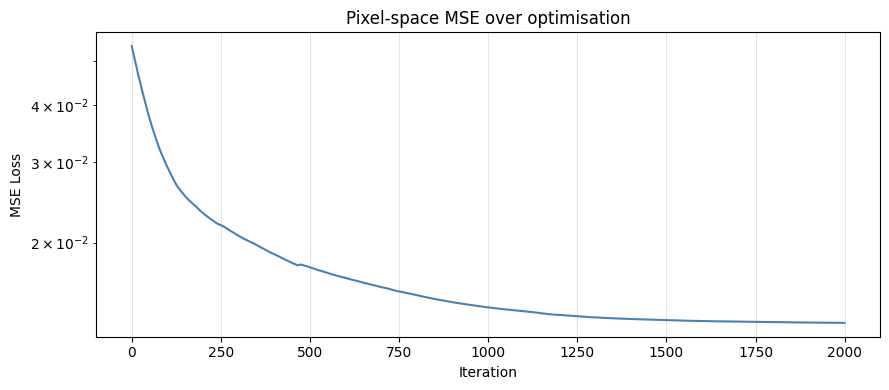

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses, color="steelblue", linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE Loss")
ax.set_title("Pixel-space MSE over optimisation")
ax.set_yscale("log")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

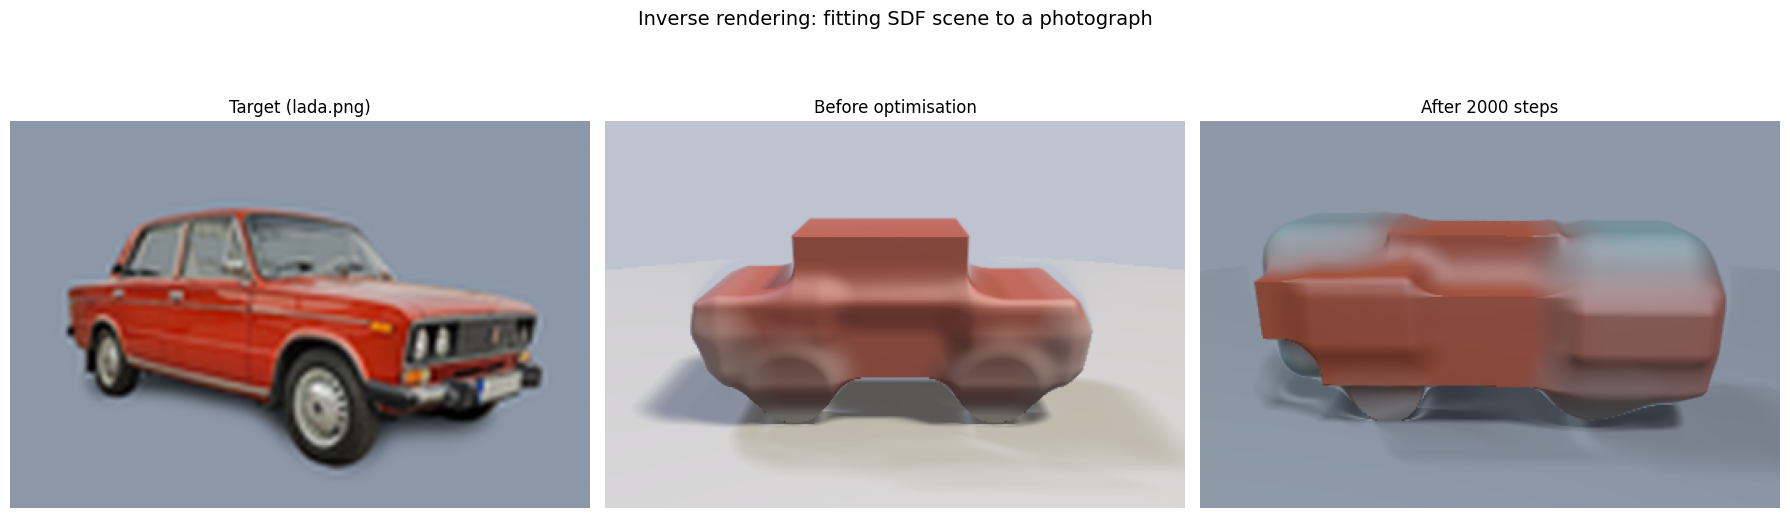

Initial loss: 0.05375
Final loss:   0.01335
Improvement:  4.0×


In [22]:
HIRES = (240, 360)
target_hires = np.array(target_pil.resize((HIRES[1], HIRES[0]), Image.LANCZOS)) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(target_hires)
axes[0].set_title("Target (lada.png)")
axes[0].axis("off")

axes[1].imshow(np.array(diff_render(free_params, resolution=HIRES)))
axes[1].set_title("Before optimisation")
axes[1].axis("off")

axes[2].imshow(np.array(diff_render(params, resolution=HIRES)))
axes[2].set_title(f"After {N_STEPS} steps")
axes[2].axis("off")

plt.suptitle("Inverse rendering: fitting SDF scene to a photograph", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.5f}")
print(f"Final loss:   {losses[-1]:.5f}")
print(f"Improvement:  {losses[0]/losses[-1]:.1f}\u00d7")

In [23]:
# ── Export optimisation trajectory as GIF ─────────────────────────────────────
frames = []
for step in sorted(snapshots.keys()):
    frame = (np.clip(snapshots[step], 0, 1) * 255).astype(np.uint8)
    frames.append(frame)

gif_path = "assets/optimization.gif"
imageio.mimsave(gif_path, frames, fps=10, loop=0)
print(f"Saved {gif_path}  ({len(frames)} frames, {len(frames) / 3:.1f}s at 3 fps)")

Saved assets/optimization.gif  (201 frames, 67.0s at 3 fps)
